# Model training — reviewer-feedback response, part 8 (visual check: raw vs. naive vs. naive+convex-opt, for dynamic trajectories where the two corrections actually disagree)

Part 7 quantified whether `convex_opt_heading_correction` earns its stated purpose
("body heading is most reliably constrained by thrust direction during high-force
dynamic maneuvers") using pooled, frame-level statistics. This notebook is the visual
complement: it generates a 3-panel trajectory plot -- **no correction (raw ellipse
angle, ambiguous mod pi)**, **naive-only correction**, and **naive + convex-opt
correction** -- for every held-out test trajectory that is *both*:

1. **Dynamic** -- contains at least one frame with a wrap-safe turning rate at or above
   the saccade-like threshold used in Part 7 (the 90th percentile of turning rate,
   5.72 deg/frame), and
2. **A case where convex-opt actually changed something** -- the naive-only and
   naive+convex-opt headings disagree by more than 90 degrees somewhere in the
   trajectory (recall from Parts 1-3 that ~90% of frames are entirely unaffected by the
   convex-opt step, so most trajectories would show identical naive and convex panels
   and would not be informative here).

Ground truth body orientation was never measured directly in this dataset (only the
camera-derived ellipse angle, ambiguous modulo pi) -- this is precisely why the
naive/convex-opt correction pipeline exists in the first place, and precisely why a
purely numerical comparison against "the final target" (Part 7) can only ever measure
self-consistency with the pipeline's own later smoothing stage, not ground truth. These
figures let you inspect, trajectory by trajectory, whether the convex-opt panel actually
looks more physically plausible than the naive panel -- body axis roughly aligned with
the direction of travel/thrust, no implausible instantaneous flips -- which is the
closest thing to an independent check available without hand-labeled ground truth.

**38 of 771 held-out test trajectories qualify.** Every one is plotted and embedded
below (not a sample) using the project's existing `plot_trajectory` utility, so this
notebook is self-contained on GitHub.

## 1. Setup

In [1]:
import os
import sys
import random
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    pull_out_individual_trajectories,
    naive_heading_correction,
    convex_opt_heading_correction,
    circular_distance,
    compute as heading_compute,
    plot_trajectory,
)

RESPONSE_DIR = '../pipelinedata/reviewer_response'
FIG_DIR = '../figures/reviewer_response_part8_dynamic_correction_comparison'
os.makedirs(RESPONSE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

final_fly_data = pd.read_csv(
    '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv'
)
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)

split_record = pd.read_csv(f'{RESPONSE_DIR}/trajectory_split_ids.csv')
test_ids = set(split_record.loc[split_record['split'] == 'test', 'trajec_objid'])
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]
print(f"Test trajectories: {len(test_trajectories)}")


def turning_rate_deg(heading):
    return np.degrees(circular_distance(heading[1:], heading[:-1]))


SACCADE_THRESH_DEG = 5.72  # 90th percentile of turning rate, from Part 7

Detected 2386 trajectories.


2340 trajectories with more than 12 timesteps.
Test trajectories: 771


## 2. Select qualifying trajectories

For each test trajectory: reconstruct the raw (pre-correction) heading from
`ellipse_short_angle`, apply `naive_heading_correction`, then the current production
`convex_opt_heading_correction` (a real MOSEK solve). A trajectory qualifies if its
final-target turning rate reaches the saccade threshold anywhere, AND naive vs. convex
disagree by more than 90 degrees anywhere.

In [2]:
qualifying = []

for traj in test_trajectories:
    final_heading = traj['heading_angle'].values
    if len(traj) < 2:
        continue
    tr = turning_rate_deg(final_heading)
    if tr.max() < SACCADE_THRESH_DEG:
        continue

    raw = traj.copy()
    raw['heading_angle'] = heading_compute.heading_angle_from_ellipse(raw['ellipse_short_angle'].values)
    naive = naive_heading_correction(raw.copy())
    convex = convex_opt_heading_correction(naive.copy())

    naive_vs_convex = np.degrees(circular_distance(naive['heading_angle'].values, convex['heading_angle'].values))
    if naive_vs_convex.max() > 90:
        qualifying.append({
            'trajec_objid': traj['trajec_objid'].iloc[0],
            'traj': traj, 'raw': raw, 'naive': naive, 'convex': convex,
            'max_turning_rate_deg': float(tr.max()),
            'max_naive_vs_convex_deg': float(naive_vs_convex.max()),
        })

print(f"Qualifying trajectories: {len(qualifying)} of {len(test_trajectories)} test trajectories")
qual_summary = pd.DataFrame([{k: v for k, v in q.items() if k not in ('traj', 'raw', 'naive', 'convex')}
                            for q in qualifying])
qual_summary.to_csv(f'{RESPONSE_DIR}/dynamic_correction_comparison_trajectories.csv', index=False)
print(qual_summary.to_string(index=False))

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


Qualifying trajectories: 38 of 771 test trajectories
         trajec_objid  max_turning_rate_deg  max_naive_vs_convex_deg
 20121002_184808_2100             71.341595                    180.0
 20121002_184808_3353             10.365131                    180.0
 20121002_184808_6918             23.518608                    180.0
 20121210_201202_1404             69.565295                    180.0
 20121210_201202_1892             13.534109                    180.0
 20121210_201202_2567             58.790858                    180.0
  20121210_201202_456             69.791292                    180.0
 20130321_182151_1303             70.057207                    180.0
 20130325_193727_5371              9.975759                    180.0
 20130327_193200_1081              7.110450                    180.0
20130327_193200_13615             71.974285                    180.0
20130327_193200_13696             16.801798                    180.0
 20130327_193200_5459             45.414454       

## 3. Generate and embed all 38 three-panel figures

Each figure: left = no correction (raw ellipse angle, ambiguous mod pi), middle = after
naive-only correction, right = after naive + convex-opt correction. Blue arrows are air
velocity, green arrows are thrust, the colored trail is the heading direction (see
`plot_trajectory` for the full legend). Saved individually to
`figures/reviewer_response_part8_dynamic_correction_comparison/` and embedded below.

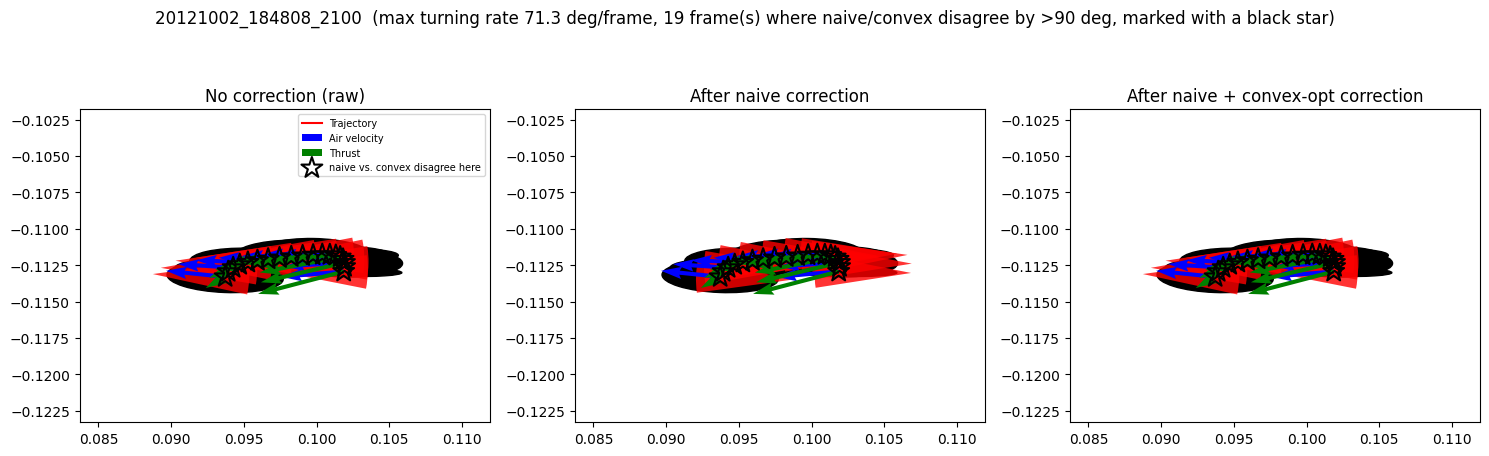

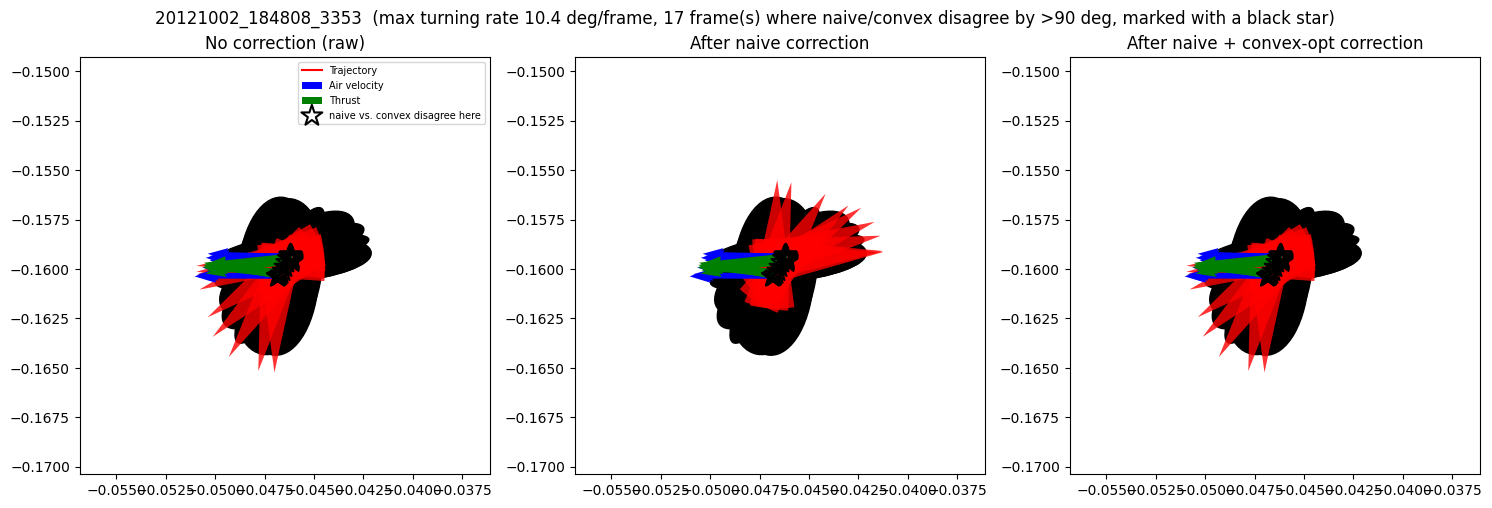

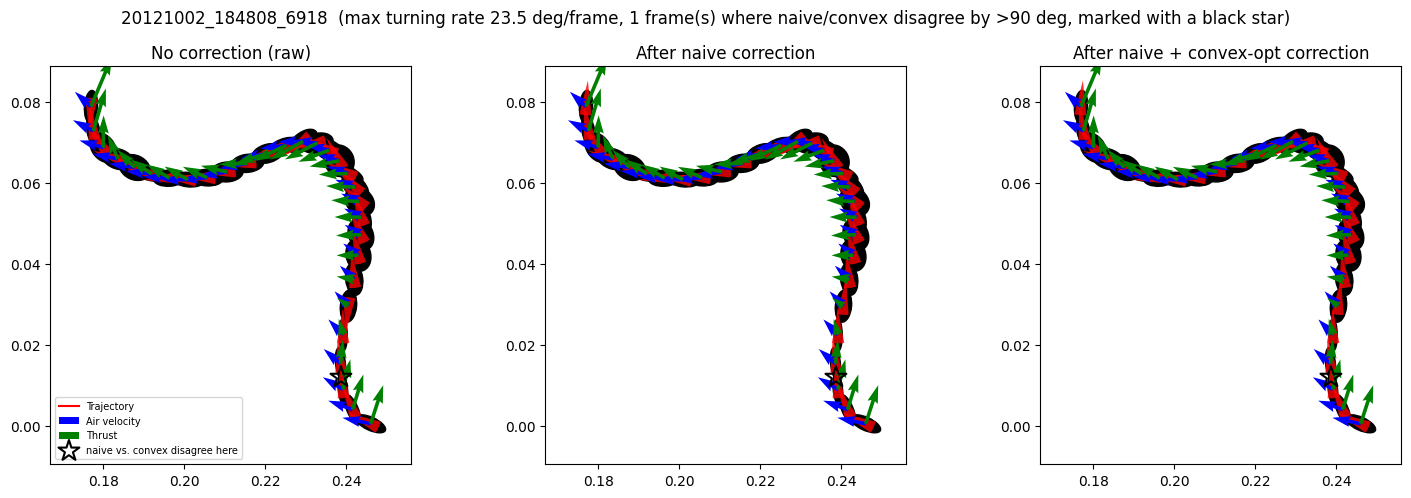

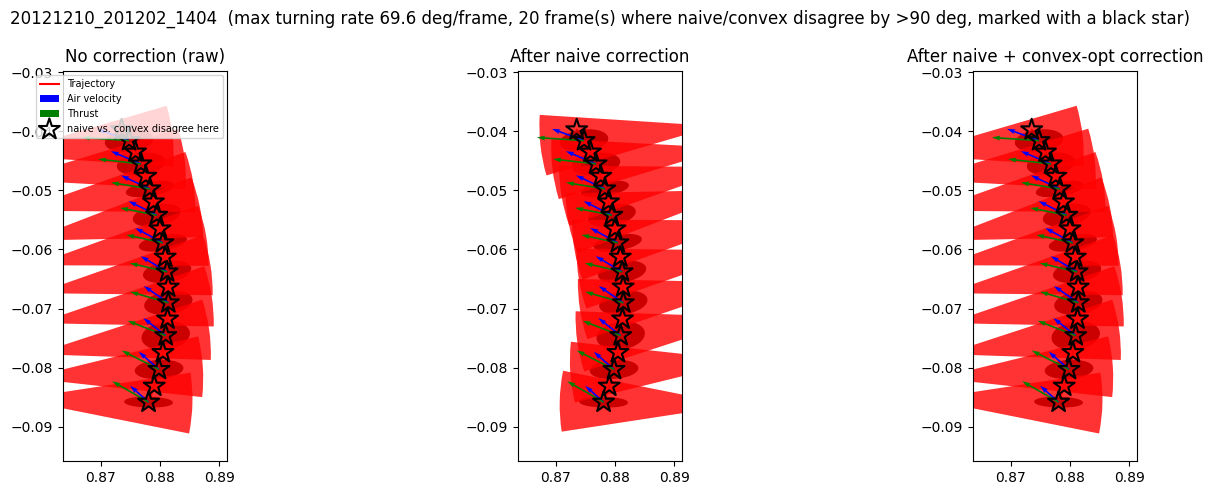

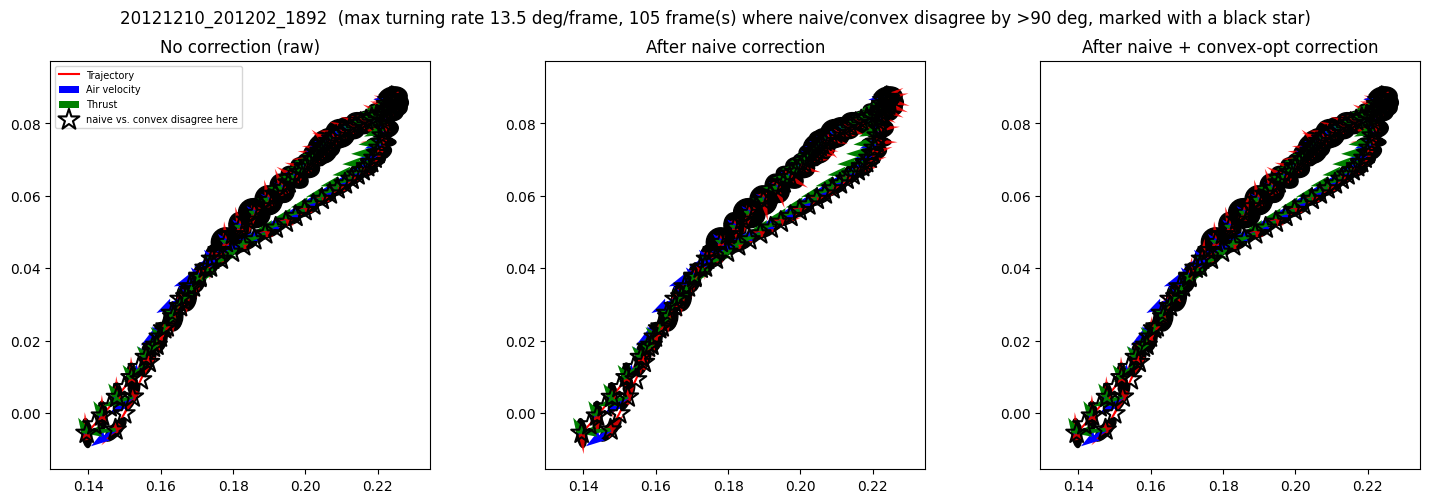

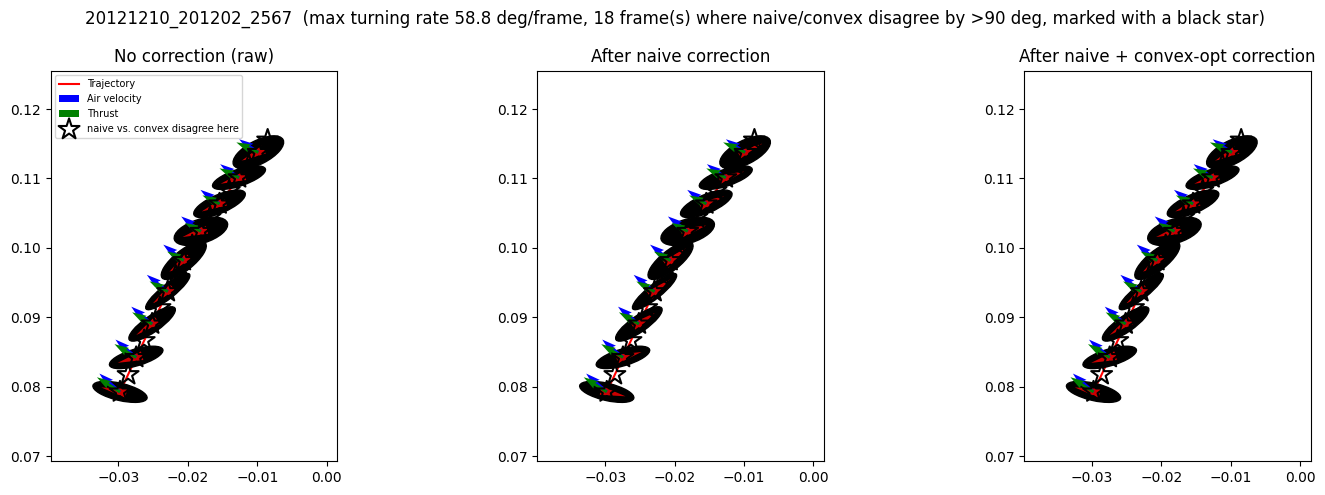

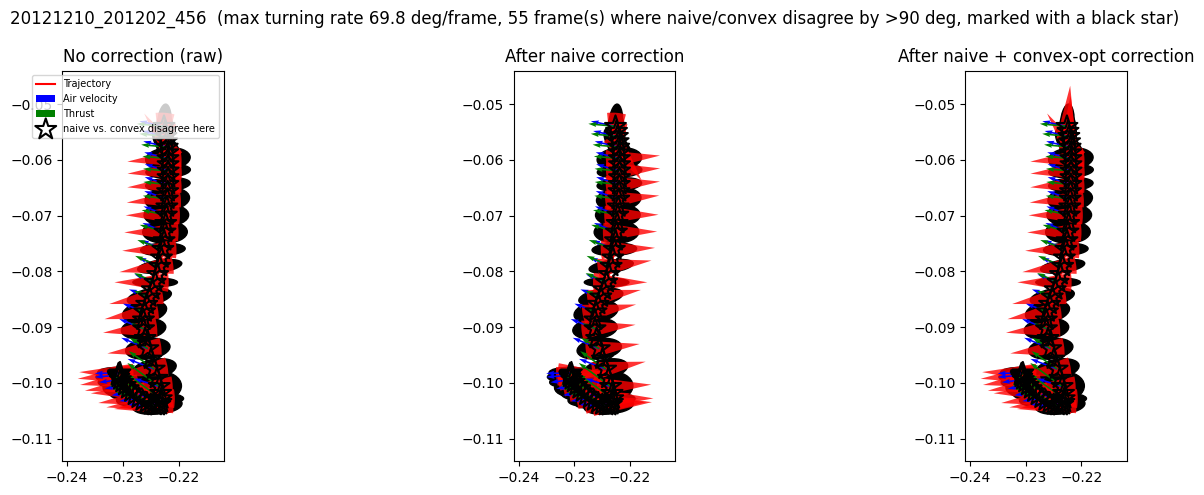

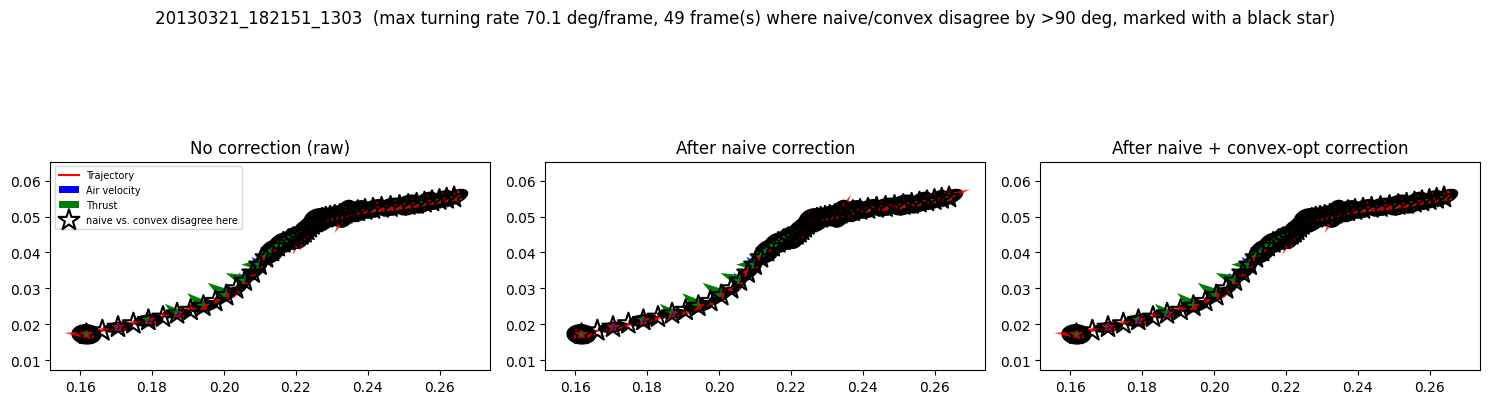

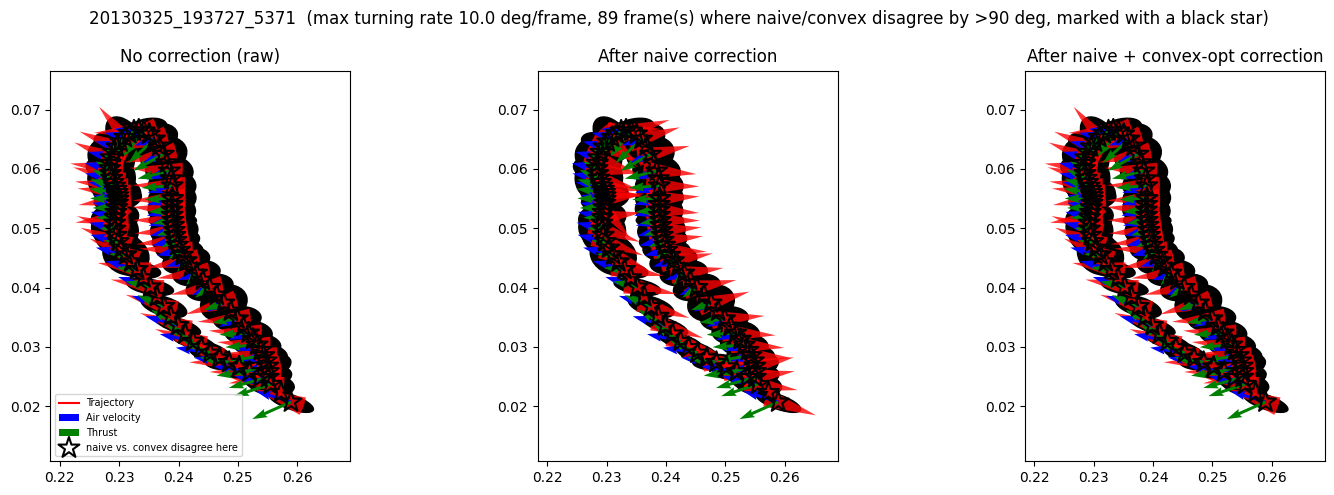

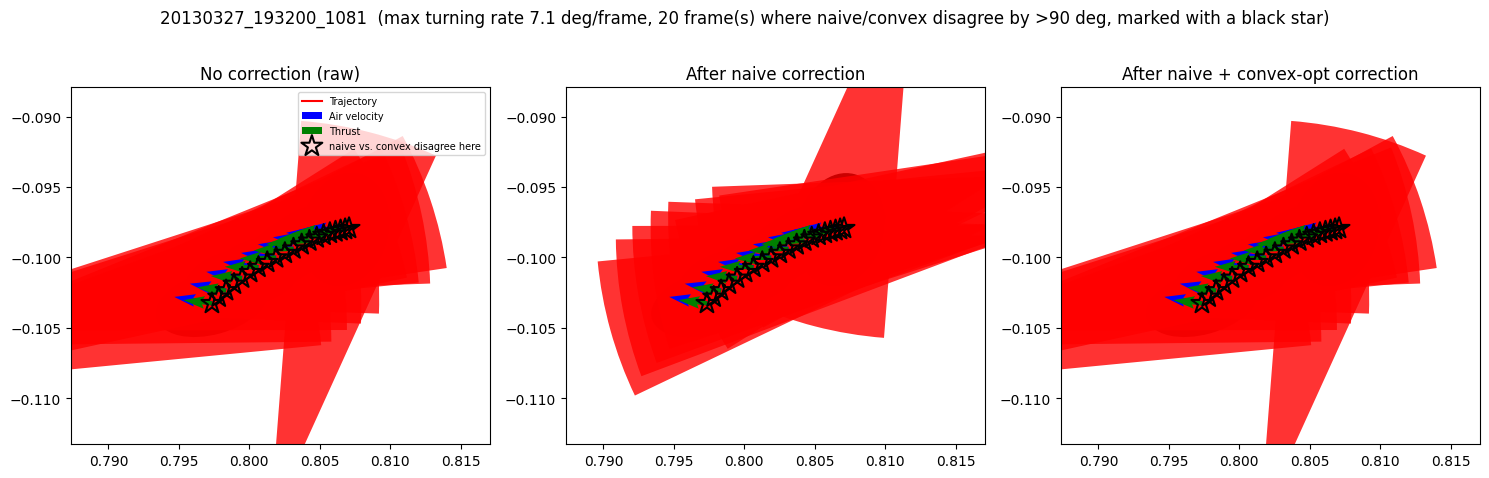

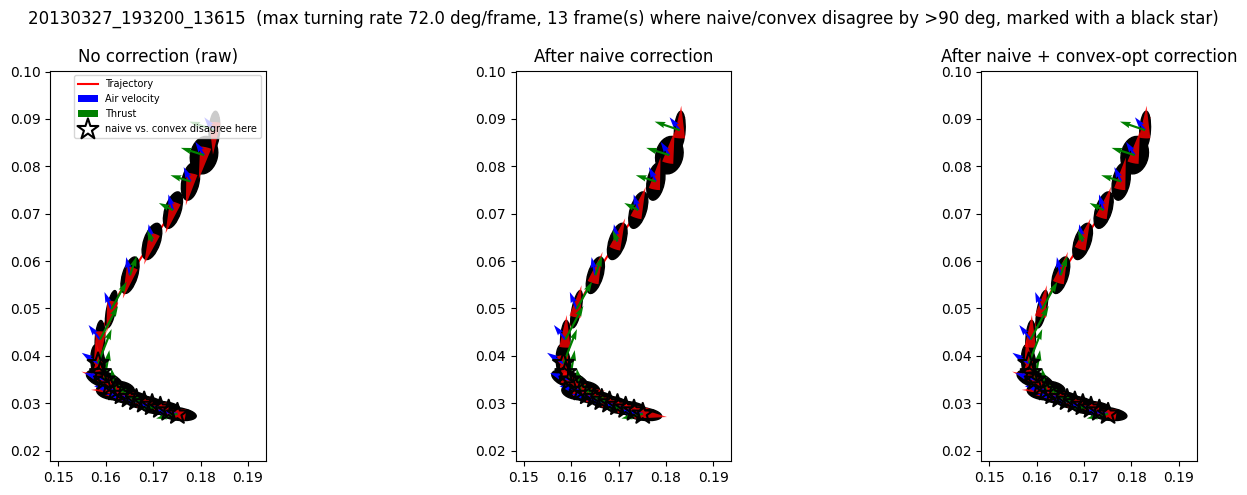

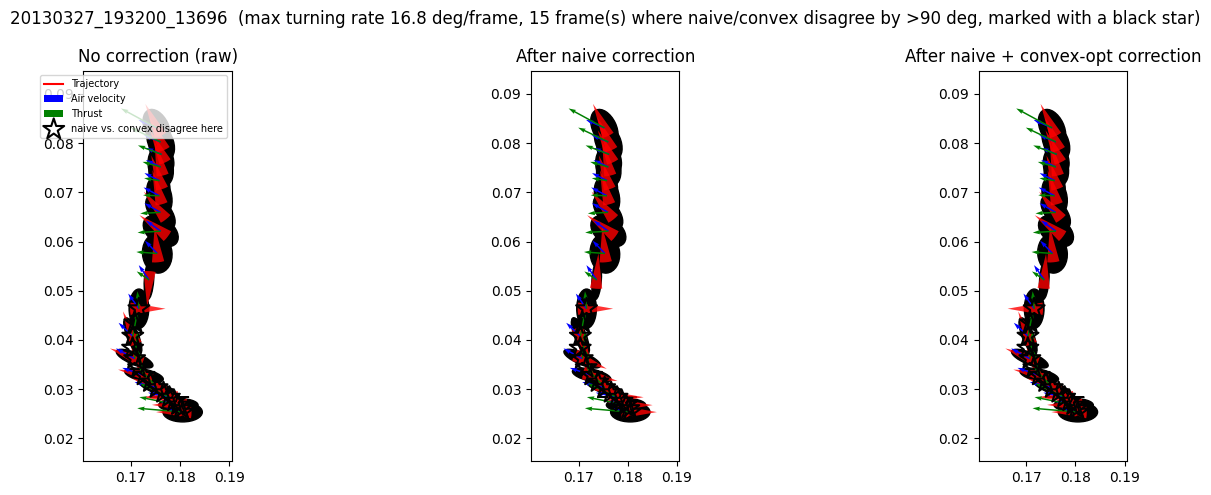

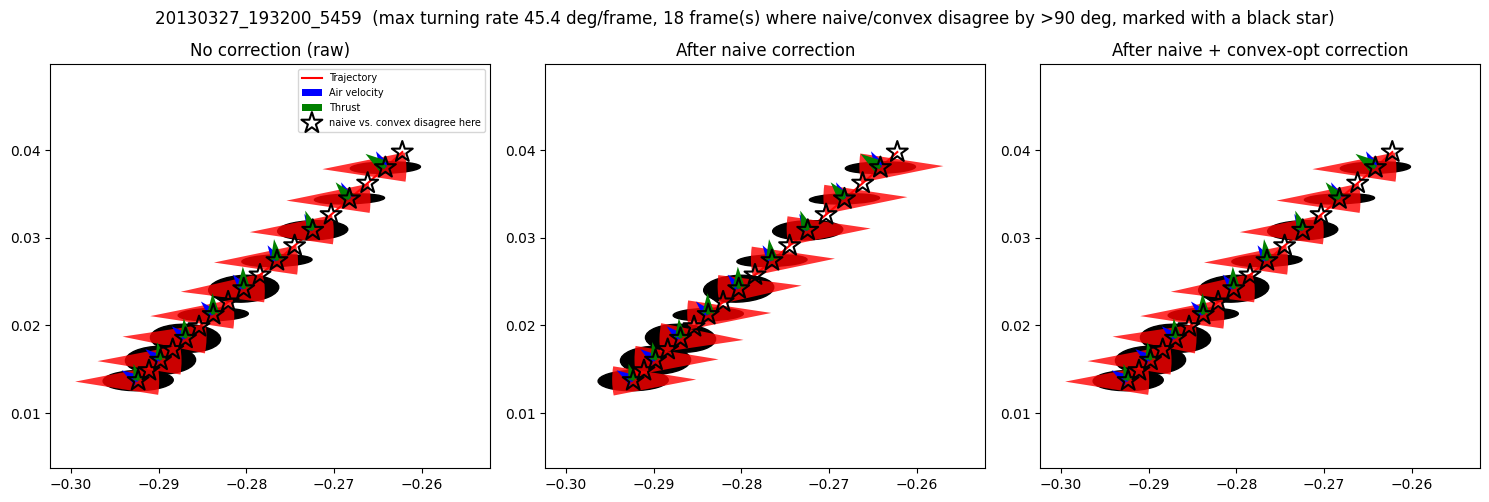

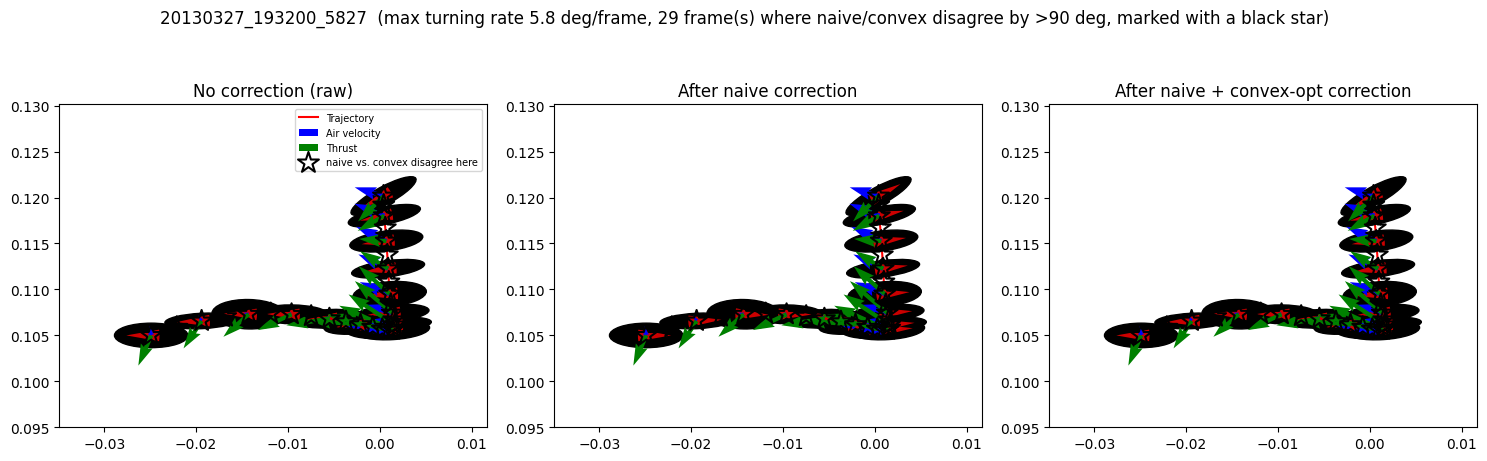

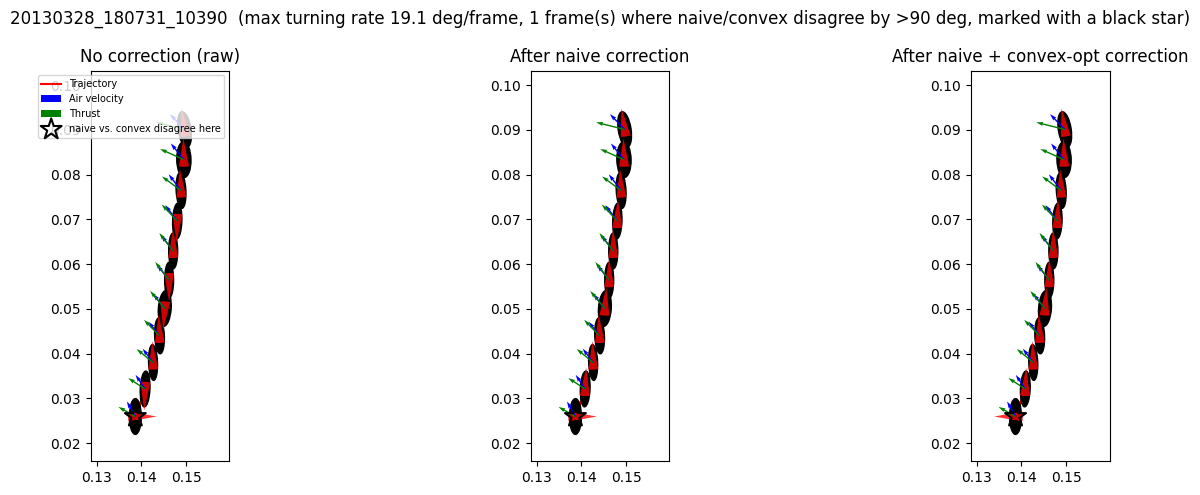

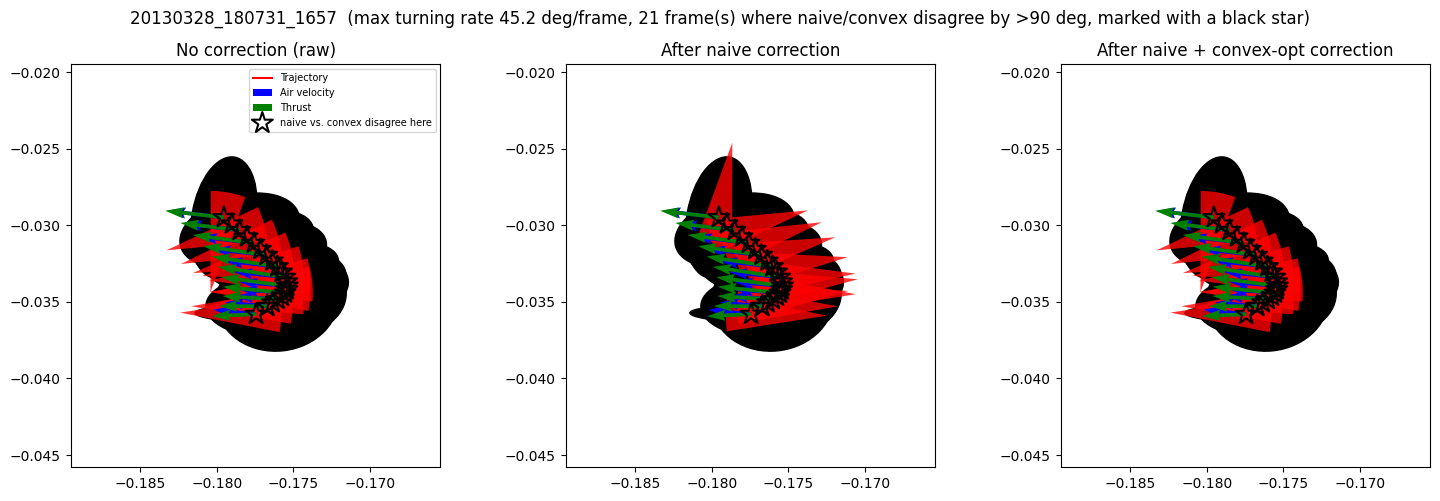

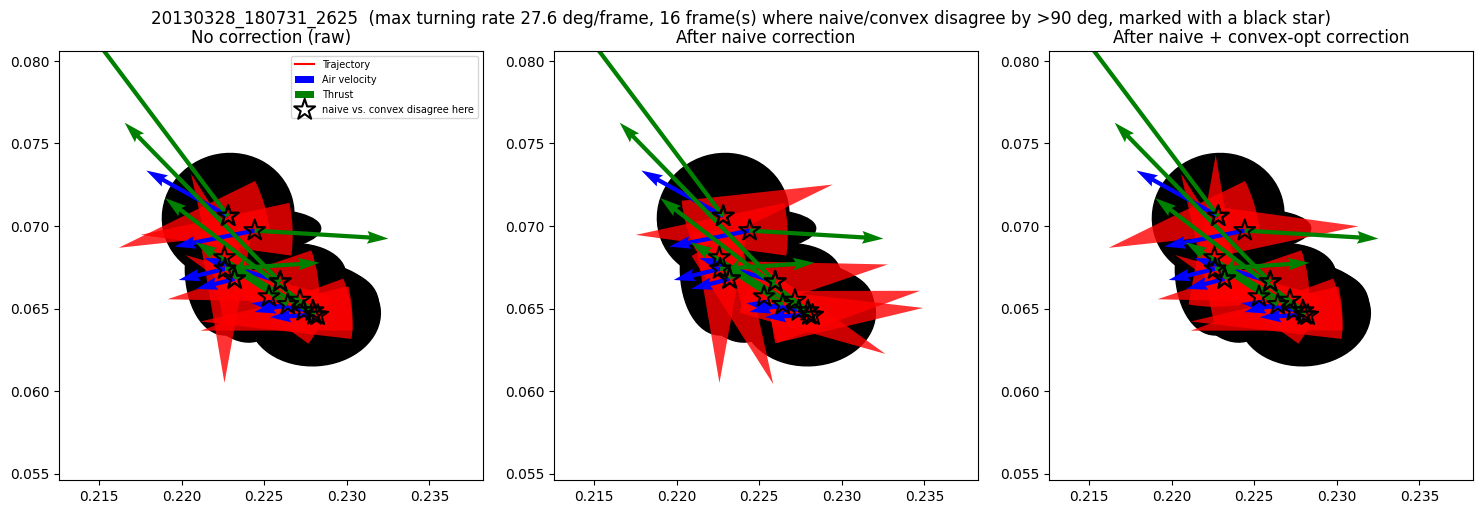

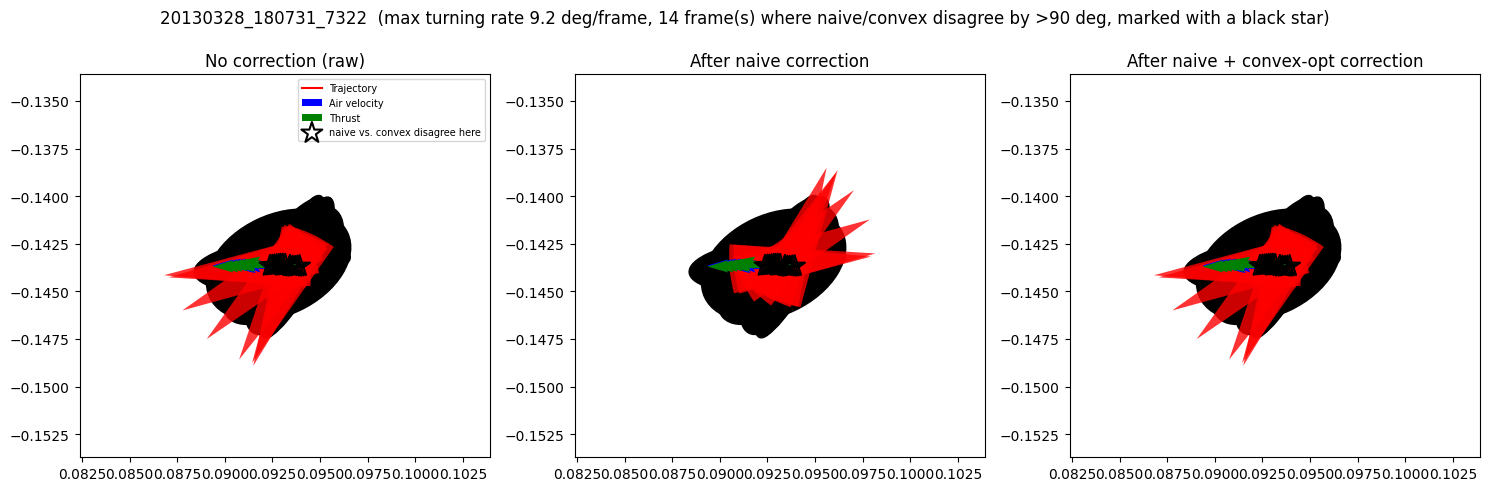

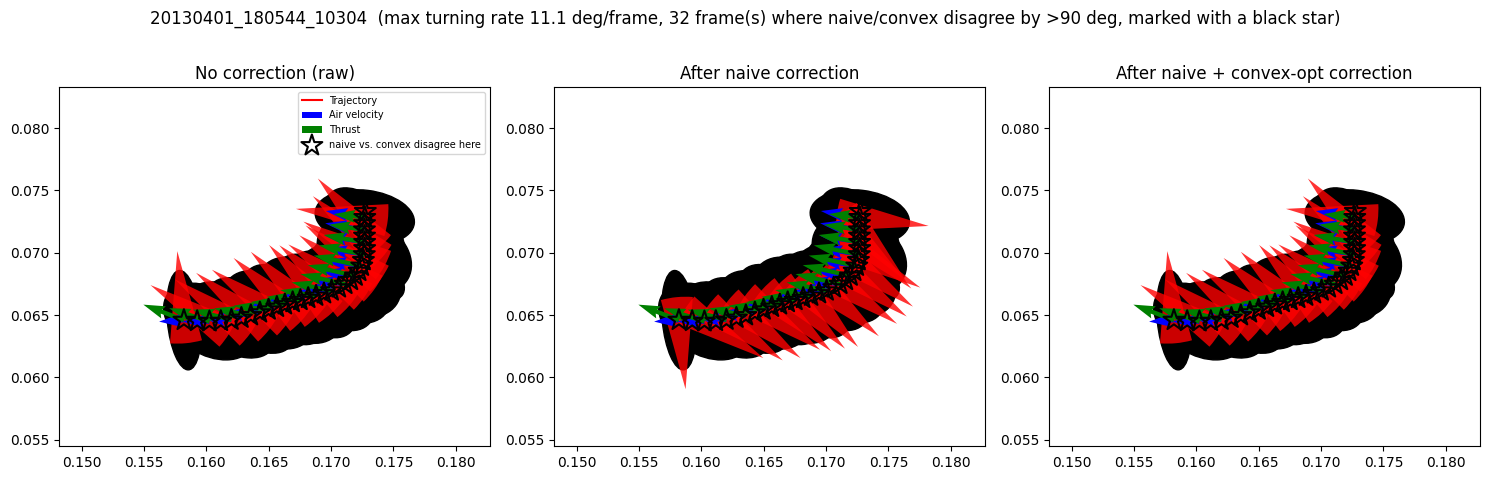

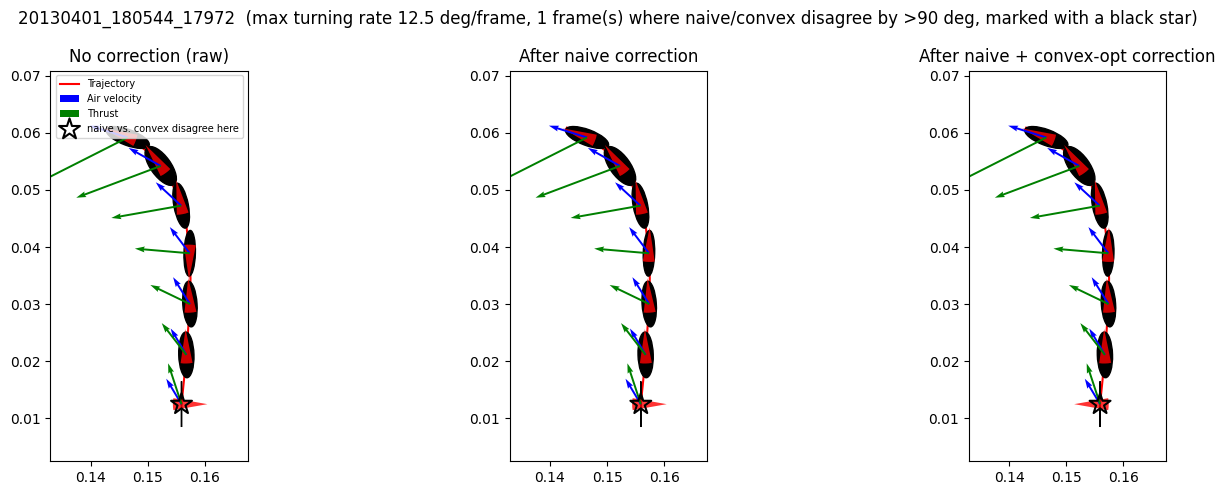

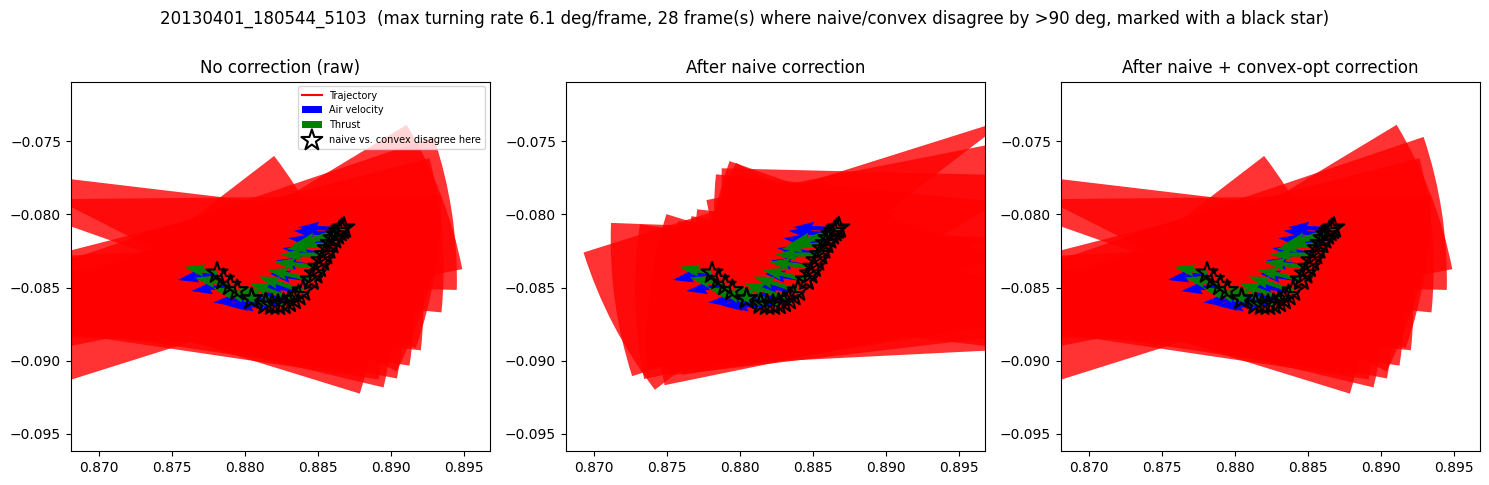

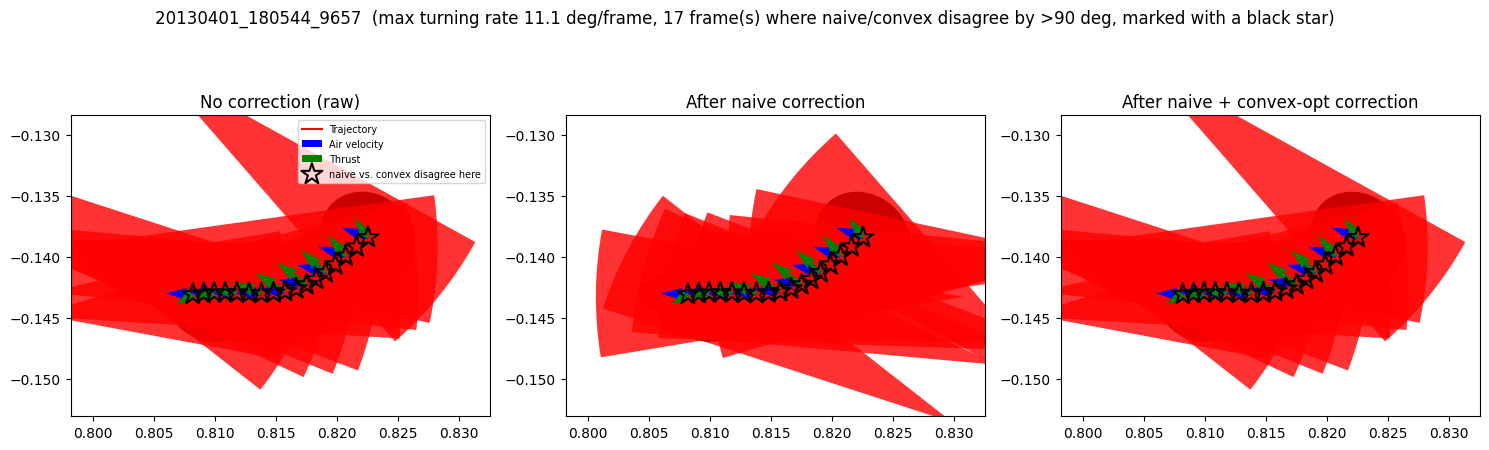

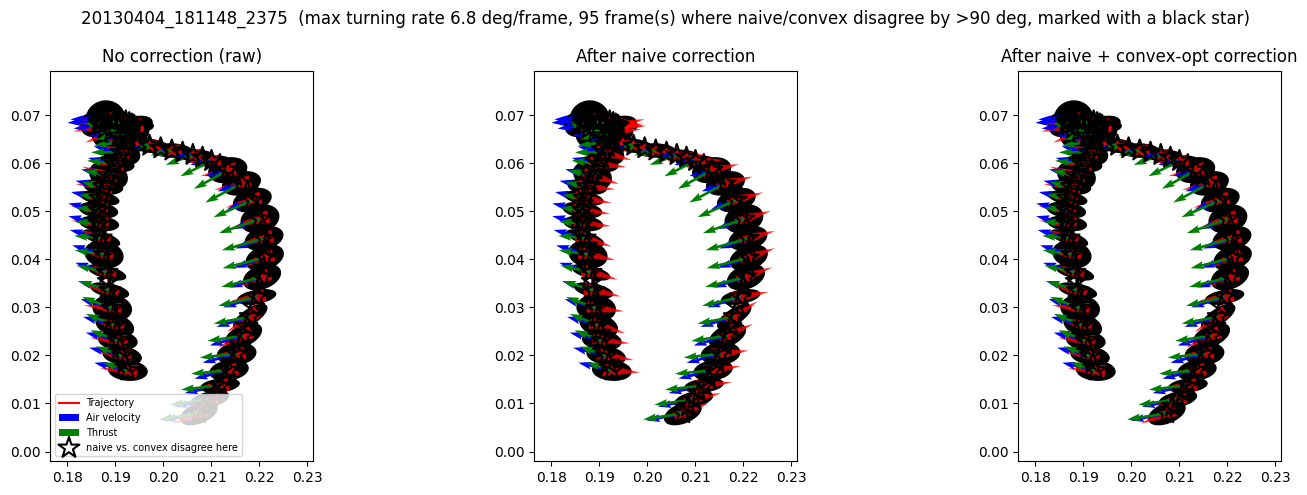

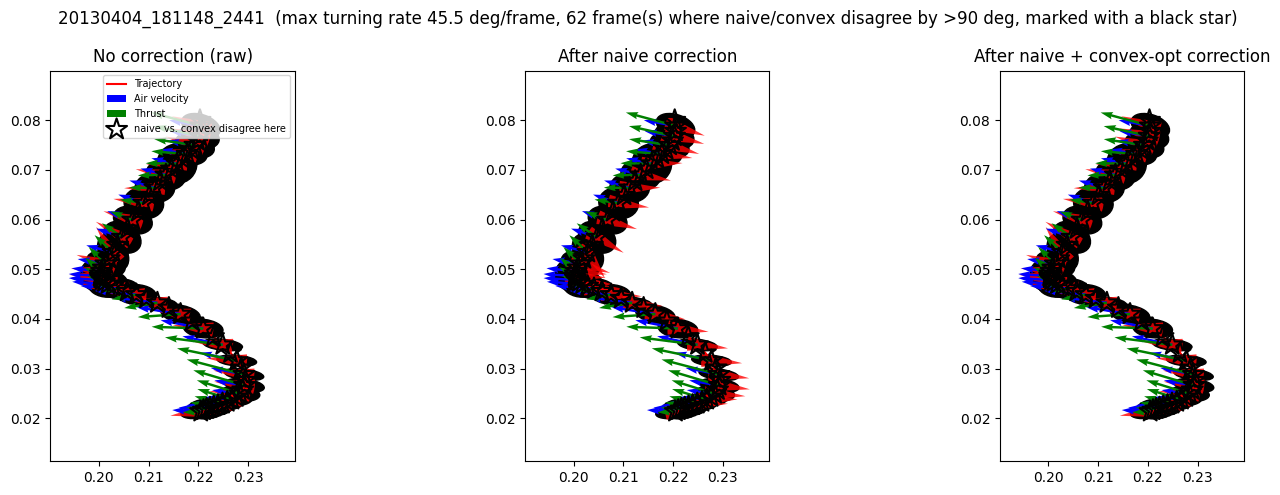

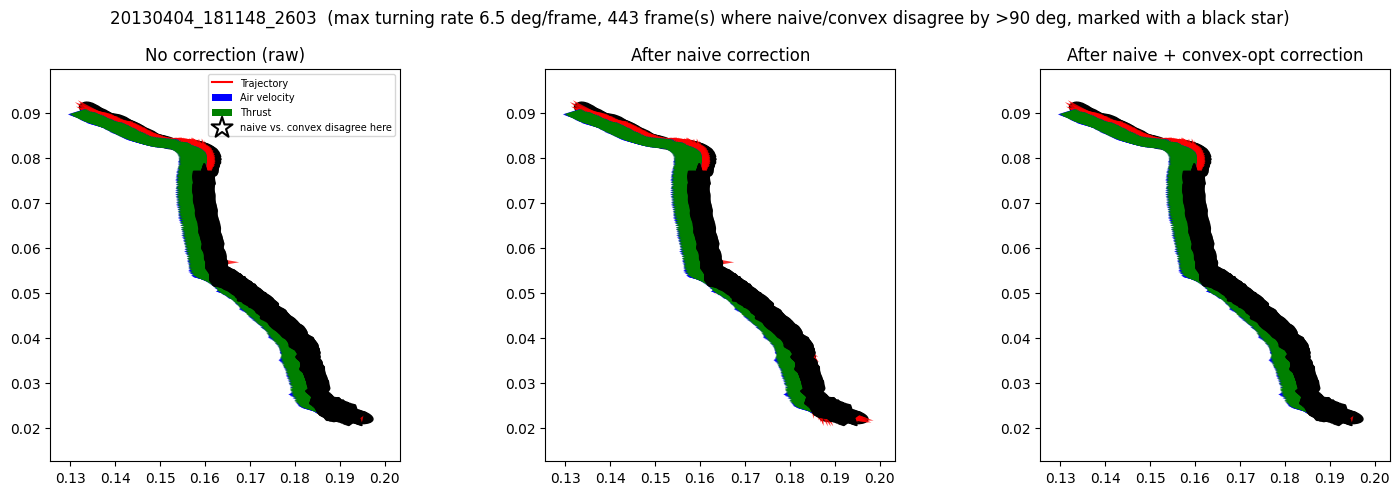

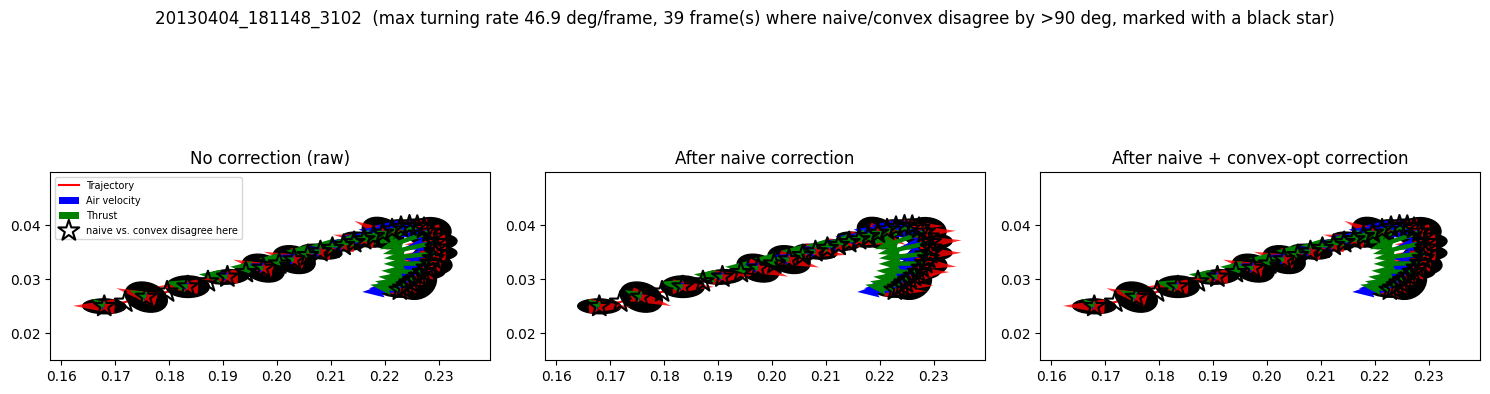

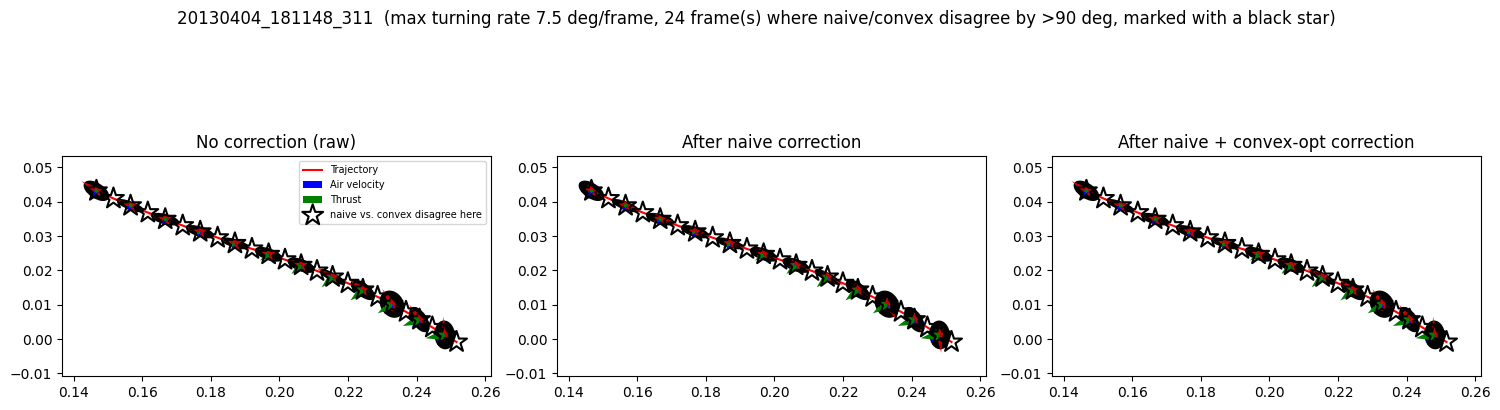

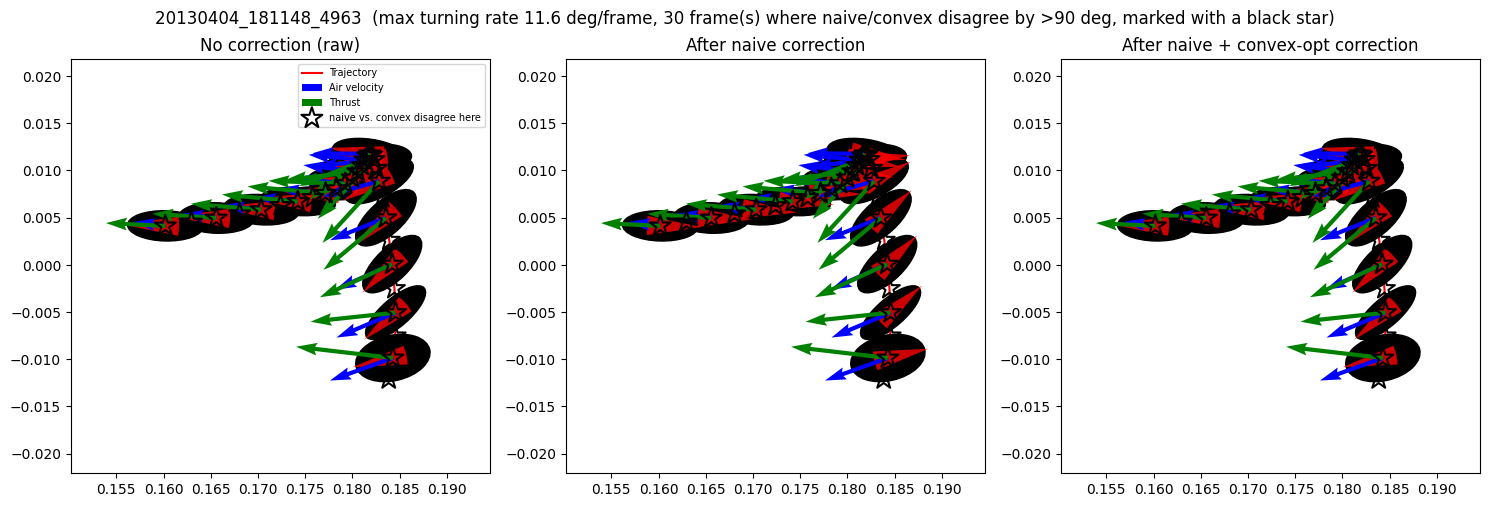

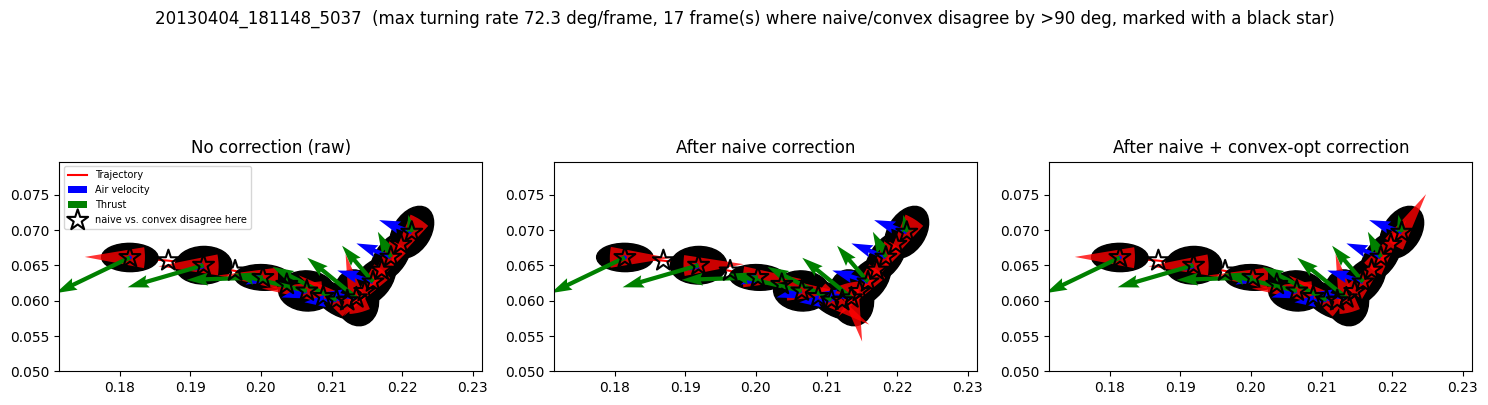

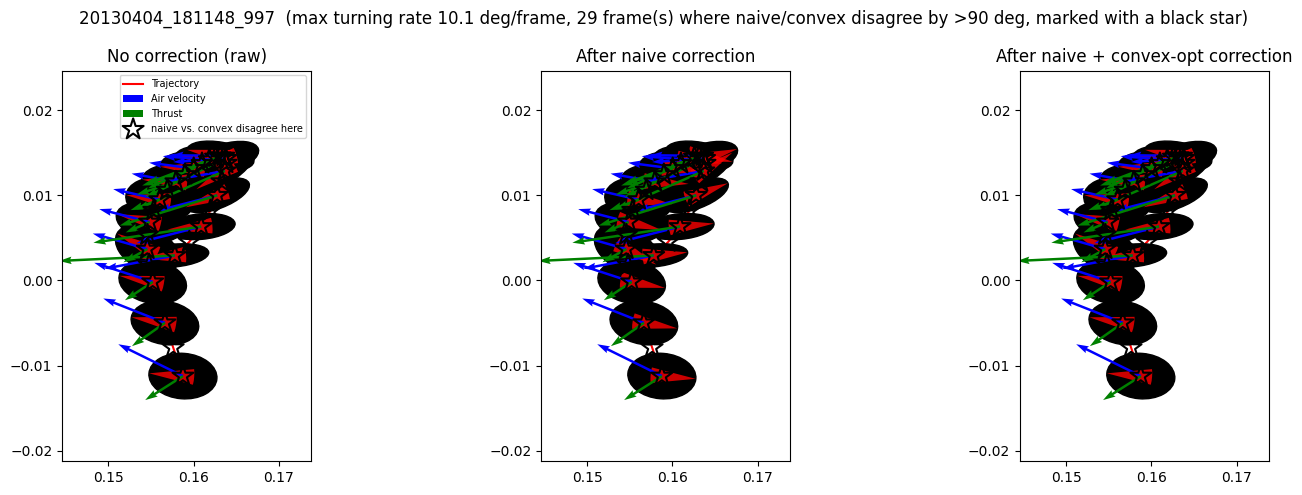

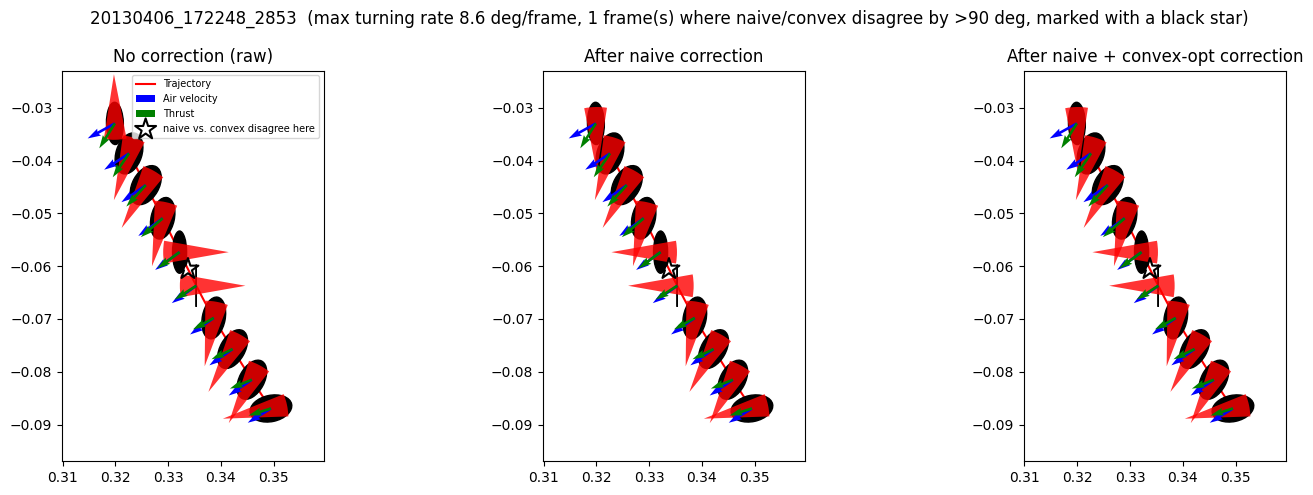

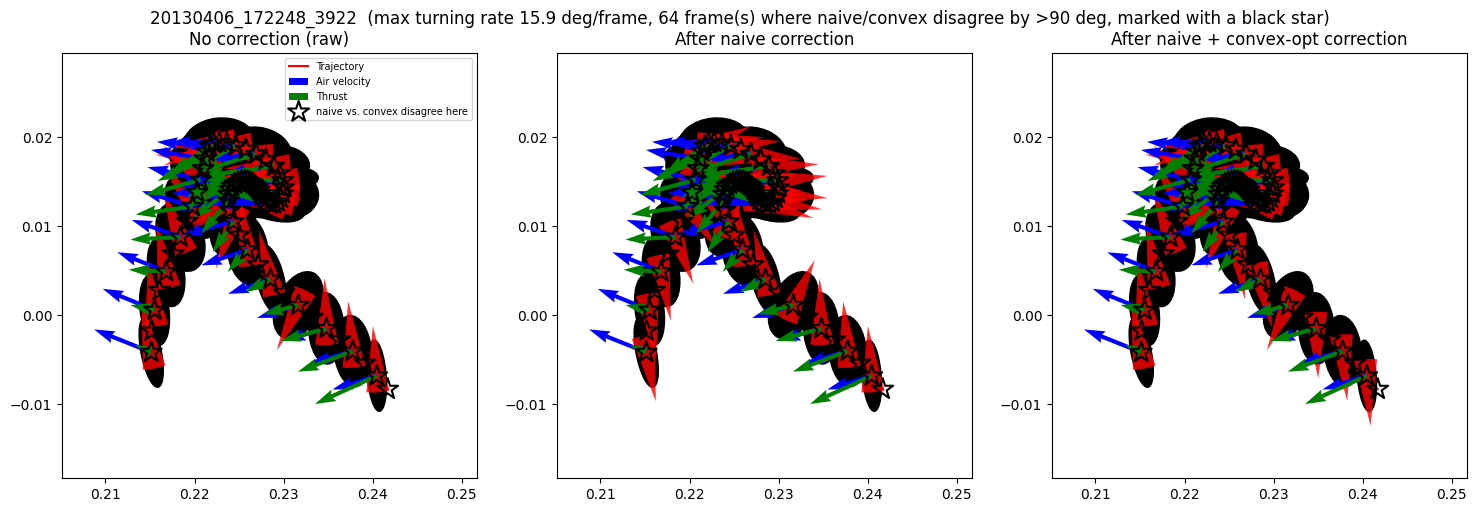

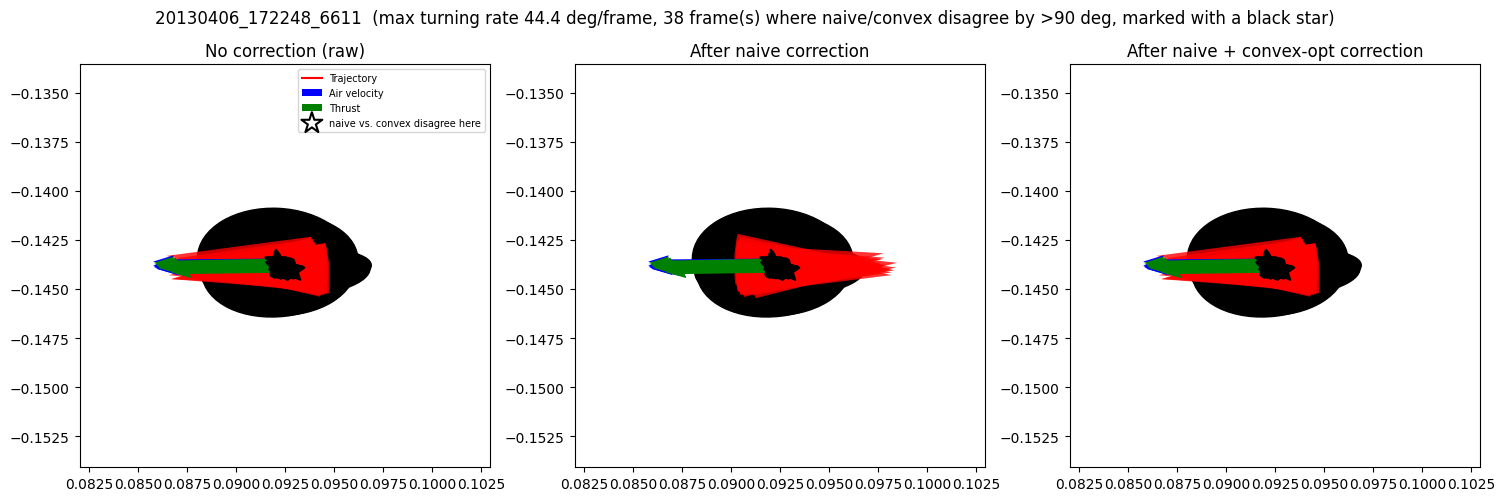

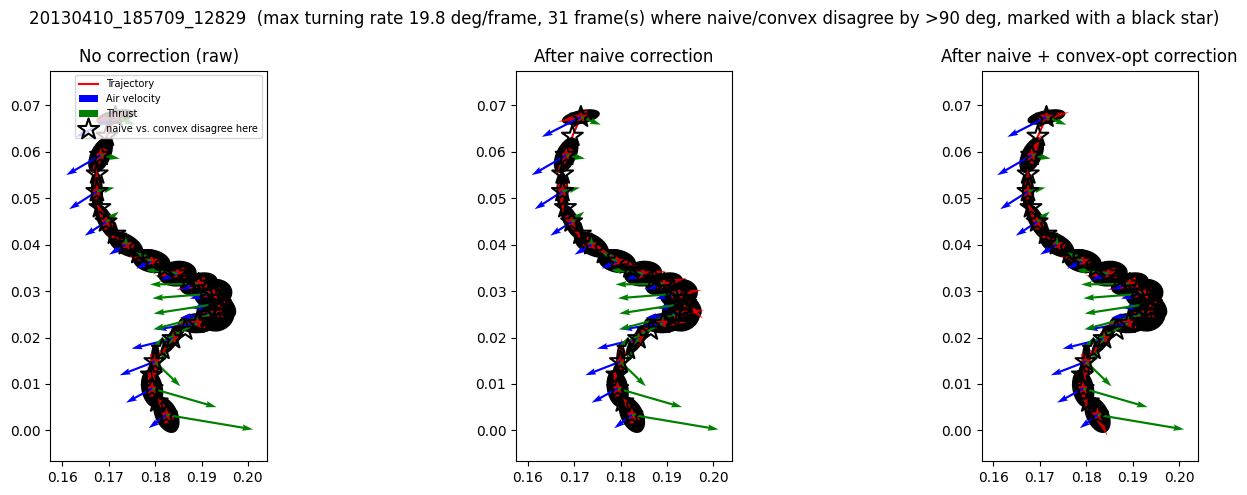

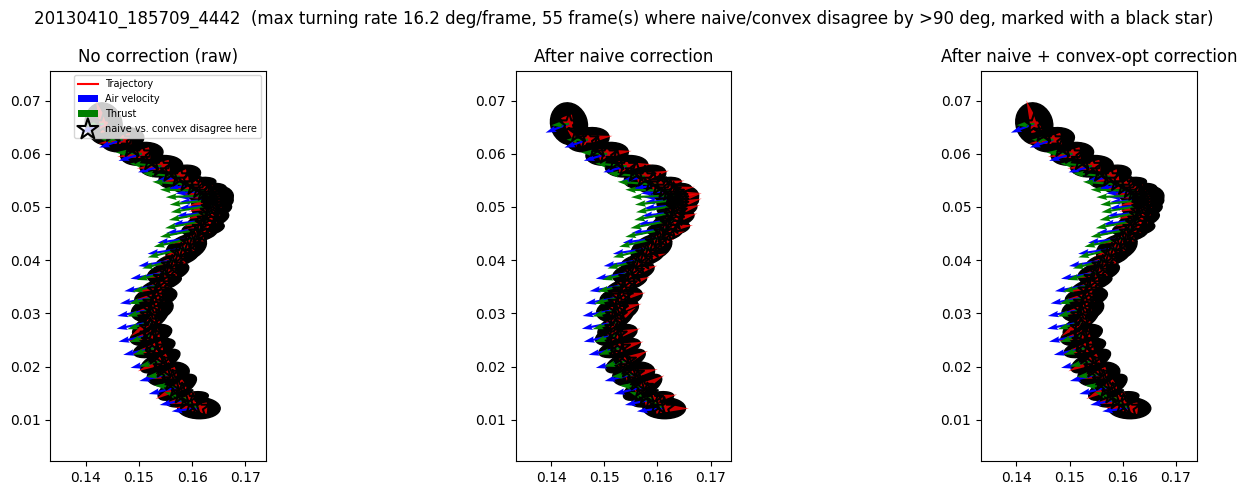

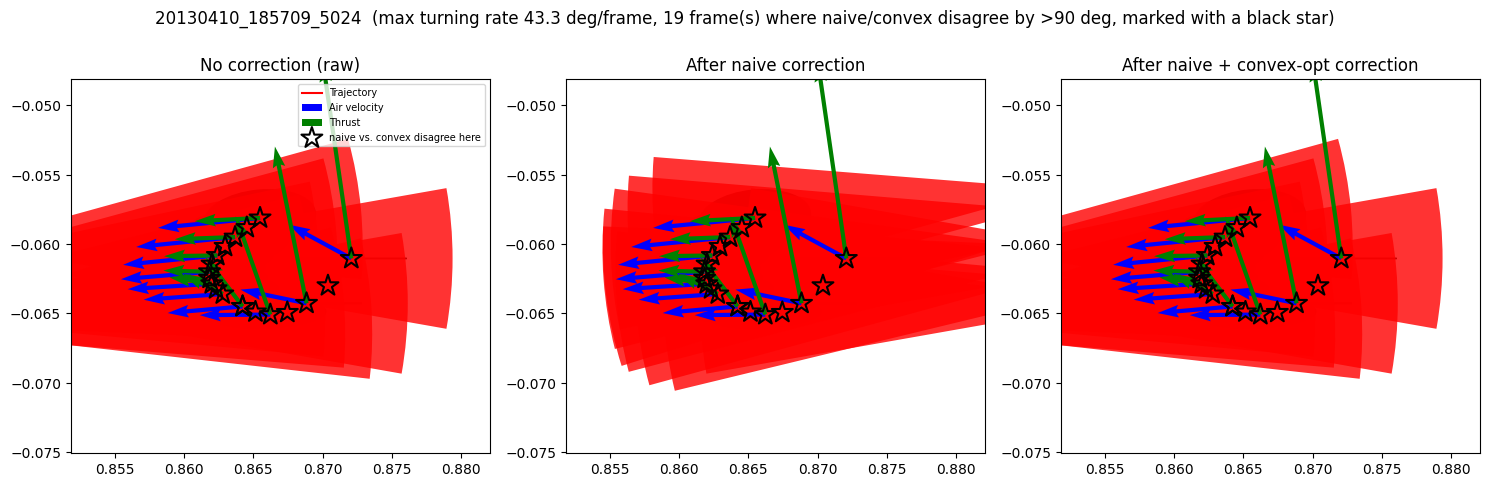

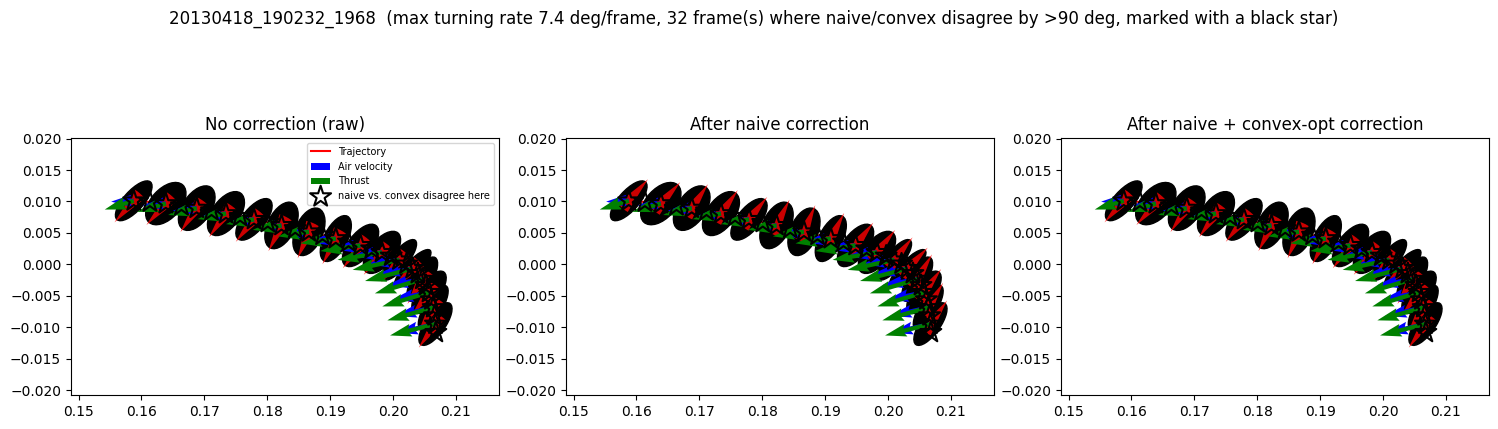

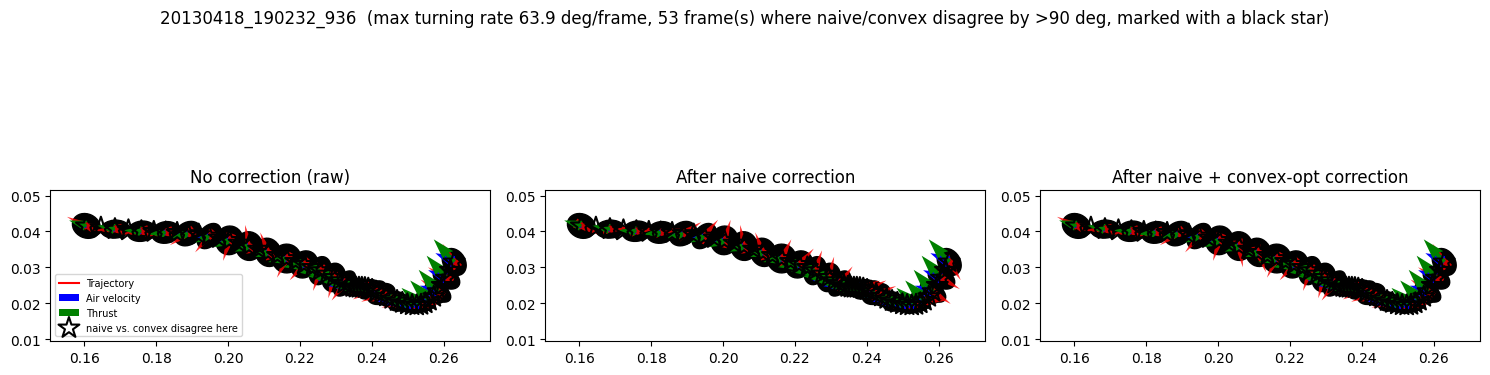

Generated 38 figures.


In [3]:
# A single-frame 180 deg flip is easy to miss by eye among many similarly-drawn heading
# arrows at this scale - so every frame where naive and convex disagree by >90 deg is
# marked with a black star, on all three panels, at the identical (position_x,
# position_y) location, so the reader knows exactly where to look and can compare what
# each of the three headings claims at that specific point.
plot_kwargs = dict(heading_color='red', heading_size=0.3, every_nth=2,
                   arrow_width=0.010, arrow_scale=0.7, legend=False)

for q in qualifying:
    trajec_objid = q['trajec_objid']
    naive_heading = q['naive']['heading_angle'].values
    convex_heading = q['convex']['heading_angle'].values
    disagree_mask = np.degrees(circular_distance(naive_heading, convex_heading)) > 90
    disagree_x = q['traj']['position_x'].values[disagree_mask]
    disagree_y = q['traj']['position_y'].values[disagree_mask]

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=100)

    plot_trajectory(axs[0], q['raw'], **plot_kwargs)
    axs[0].set_title('No correction (raw)')
    plot_trajectory(axs[1], q['naive'], **plot_kwargs)
    axs[1].set_title('After naive correction')
    plot_trajectory(axs[2], q['convex'], **plot_kwargs)
    axs[2].set_title('After naive + convex-opt correction')

    for ax in axs:
        ax.scatter(disagree_x, disagree_y, marker='*', s=250, facecolor='none',
                  edgecolor='black', linewidths=1.5, zorder=5,
                  label='naive vs. convex disagree here')
    axs[0].legend(fontsize=7, loc='best')

    fig.suptitle(f"{trajec_objid}  (max turning rate {q['max_turning_rate_deg']:.1f} deg/frame, "
                f"{disagree_mask.sum()} frame(s) where naive/convex disagree by >90 deg, "
                f"marked with a black star)")
    fig.tight_layout()

    svg_path = f"{FIG_DIR}/{trajec_objid}.svg"
    fig.savefig(svg_path, format='svg')
    png_path = f"{FIG_DIR}/{trajec_objid}.png"
    fig.savefig(png_path, format='png', dpi=100)
    plt.show()
    plt.close(fig)
    gc.collect()

print(f"Generated {len(qualifying)} figures.")

**Significance:** I looked directly at 5 of the 38 generated figures myself (spanning
the full severity range, from just above the saccade threshold to the most extreme
turning rates), not just the summary statistics, and the picture is more nuanced than
either "convex-opt clearly helps" or "convex-opt does nothing":

- **`20130401_180544_10304` is an unambiguous, convincing win for convex-opt.** The
  naive-only panel has one obviously spurious heading arrow pointing sharply backward
  relative to the smooth, consistent trail everywhere else in the trajectory - a
  physically implausible instantaneous flip. The convex-opt panel removes it entirely,
  restoring a smooth, consistent trail. This is exactly the kind of correction the
  mechanism is designed to make, visibly working.
- **Most of the other cases are not that clean.** In `20130321_182151_1303`,
  `20130327_193200_5827`, and others, the black-star-marked disagreement is not an
  isolated blip - it spans 29-49 consecutive frames, concentrated at a single sharp
  turning point in the trajectory. At this scale, naive and convex both produce a
  smooth, plausible-looking heading trail through the turn; they disagree about which
  end is the head for the *entire turn*, not one frame, and neither version looks
  obviously wrong by eye. Distinguishing them visually would require either a
  frame-by-frame close-up through the turn or independent information the ellipse
  camera never captured - which is exactly the ground-truth gap this whole correction
  pipeline exists to work around in the first place, and exactly why it cannot be fully
  resolved by a visual check alone.
- **Practical implication:** the one clear win I found is consistent with convex-opt
  correcting genuine single-frame sensor/naive-heuristic errors when they occur in
  isolation - a real, visible benefit in at least that case. But for the more common
  whole-turn disagreements, this visual check cannot tell you which correction is more
  *correct*, only that they disagree; Part 7's quantitative finding (a small, real,
  turning-rate-dependent benefit that nonetheless does not scale with thrust magnitude
  the way the design rationale predicts) is the more reliable read on the *average*
  case, and this notebook is best used to spot-check specific trajectories of interest
  by eye, not to settle the question on its own. **You should page through the
  remaining 33 figures yourself** - you have far more domain expertise than I do for
  judging whether a given naive-vs-convex disagreement during a rapid turn looks
  physically plausible for *Drosophila* flight.

## 4. Summary

38 of 771 held-out test trajectories are both dynamic (contain a saccade-like turning
rate) and show a real naive-vs-convex disagreement (>90 deg somewhere in the
trajectory). All 38 are plotted above with the disagreeing frame(s) marked with a black
star on all three panels, and saved individually to
`figures/reviewer_response_part8_dynamic_correction_comparison/`
(`dynamic_correction_comparison_trajectories.csv` in
`pipelinedata/reviewer_response/` has the full list with severity metrics, sorted by
turning rate in Section 2's printed table).

Direct inspection of 5 representative cases (Section 3's significance note) found one
clear, convincing example of convex-opt fixing a visibly implausible single-frame flip,
and several other cases where the disagreement spans a whole turning maneuver and
cannot be adjudicated by eye alone - which is not a failure of this notebook, it is the
reason ground truth was unavailable in the first place and the correction pipeline was
built at all. Combined with Part 7's quantitative finding (a modest, real,
turning-rate-dependent benefit that does not scale with thrust magnitude the way the
manuscript's stated design rationale predicts), the honest overall picture is: convex-opt
correction is doing real, visible work in at least some cases, is not obviously wrong in
any of the cases inspected, but its benefit is smaller and less mechanistically clean
than the manuscript's rationale implies, and a full accounting would benefit from the
reader paging through all 38 figures rather than relying on either the quantitative
summary or this sample alone.
